## Chemin
*  1 Load the Breast Cancer METABRIC.csv
* 2 Clean the Dataset
* 3 Explore the Dataset (Univariate analysis(pair plot, scatter, boxplot) and Multivariate analysis(corelation (heatmap)))
* 4 Split the Dataset into Train and Test (data.sample, drop ...) => Train_set and Test_set
* 5 Check Dataset Statistics (describe, statical test and one)
* 6 Split the Features from Target Values (pop ..) => X(feature) and Y(label)* 7 Normalize the Feature Data (numerical (min_max, std_scaler), categorical (one-hot, ...))
* 8 Test many model and Choose the best model
* 9 Evaluate with the best metric and explain your result

  1 Load the Breast Cancer METABRIC.csv
  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, f_regression
from utils import SurvivalModelWrapper, SurvivalDataProcessor

# Lecture du dataset et mise en forme

In [3]:
df_raw = pd.read_csv('projet.csv', 
    na_values="?",        # Treat '?' as missing values (NaN).
    comment="\t",         # Lines starting with tab ("\t") are comments. Ignore.
    sep=",",              # Use comma as a separator.
    skipinitialspace=True,# Skip initial spaces in the data.
)

 2 Clean the Dataset

In [9]:
# Après analyses ses donnée ne sont pas itiles pour la prédiction car peuvent causer des bias
exculde_features = ["patient's_vital_status", "cancer_type_detailed", "cancer_type", "oncotree_code", 
                    "3-gene_classifier_subtype", "primary_tumor_laterality", "sex", "hormone_therapy"]

# Tu passes ton DataFrame brut et tes choix
processor = SurvivalDataProcessor(
    data=df_raw, 
    global_survie=True, # Change ici pour passer en récidive
    exclude_cols=exculde_features # Choix de la méthode d'imputation
)

# Sélectionner uniquement les colonnes Numeriques
num_columns,  cat_columns = processor.get_features()
df, df_original = processor.get_data()

print(f'Nombre de données numériques : {len(num_columns)}', f'Nombre de données catégorielles : {len(cat_columns)}', sep='\n')

Nombre de données numériques : 7
Nombre de données catégorielles : 18


In [10]:
df_cat = df[cat_columns].copy()
df_num = df[num_columns].copy()
df, df_original = processor.get_data()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1981 entries, 0 to 1984
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   patient_id                      1981 non-null   object  
 1   age_at_diagnosis                1981 non-null   float64 
 2   type_of_breast_surgery          1955 non-null   object  
 3   cellularity                     1917 non-null   object  
 4   chemotherapy                    1980 non-null   object  
 5   pam50_+_claudin-low_subtype     1980 non-null   object  
 6   cohort                          1981 non-null   category
 7   er_status_measured_by_ihc       1938 non-null   object  
 8   er_status                       1981 non-null   object  
 9   neoplasm_histologic_grade       1893 non-null   category
 10  her2_status_measured_by_snp6    1980 non-null   object  
 11  her2_status                     1980 non-null   object  
 12  tumor_other_histologic_su

In [25]:
df["tumor_stage"].unique()

[2.0, 1.0, 4.0, 3.0, 0.0, NaN]
Categories (5, float64): [0.0, 1.0, 2.0, 3.0, 4.0]

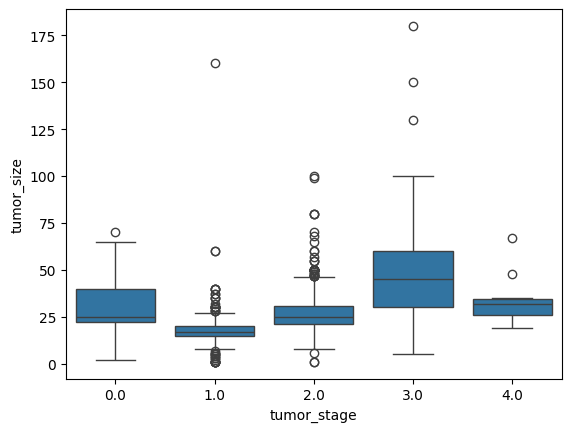

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="tumor_stage", y="tumor_size")
plt.show()

In [ ]:
df["tumor_size"] = df.groupby("tumor_stage")["tumor_size"].transform(lambda x: x.fillna(x.median()))

C:\Users\goudj\AppData\Local\Temp\ipykernel_74580\261522132.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["tumor_size"] = df.groupby("tumor_stage")["tumor_size"].transform( lambda x: x.fillna(x.median()) )


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1981 entries, 0 to 1984
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   patient_id                      1981 non-null   object  
 1   age_at_diagnosis                1981 non-null   float64 
 2   type_of_breast_surgery          1955 non-null   object  
 3   cellularity                     1917 non-null   object  
 4   chemotherapy                    1980 non-null   object  
 5   pam50_+_claudin-low_subtype     1980 non-null   object  
 6   cohort                          1981 non-null   category
 7   er_status_measured_by_ihc       1938 non-null   object  
 8   er_status                       1981 non-null   object  
 9   neoplasm_histologic_grade       1893 non-null   category
 10  her2_status_measured_by_snp6    1980 non-null   object  
 11  her2_status                     1980 non-null   object  
 12  tumor_other_histologic_su

In [ ]:
#hormone_therapy ou er_status_measured_by_ihc
one_hot_features = ["type_of_breast_surgery", "chemotherapy", "pam50_+_claudin-low_subtype", "er_status_measured_by_ihc", "her2_status_measured_by_snp6", 
                    "inferred_menopausal_state", "integrative_cluster",  "pr_status", "radio_therapy"]

ordinal_features = {"neoplasm_histologic_grade": [1, 2, 3], 
                    "tumor_stage": [1, 2, 3, 4], 
                    "cellularity": [1, 2, 3]
                    }

num_features = ["mutation_count", "nottingham_prognostic_index", "lymph_nodes_examined_positive", "age_at_diagnosis"]

In [5]:
rsf = RandomSurvivalForest(
    n_estimators=400,
    min_samples_split=500,
    min_samples_leaf=250,
    random_state=42
)

gsf = GradientBoostingSurvivalAnalysis(
    n_estimators= 200,
    min_samples_split = 400,
    min_samples_leaf = 250,
)

cox = CoxPHSurvivalAnalysis(
    alpha=0.5, 
    ties="breslow"
)

# Model avec categorical variables
La tu definir les variable comme en haut:

ER / PR / HER2 status
Histologic Grade
Tumor Stage
Histologic Type

In [ ]:
non_utile = ["patient's_vital_status", "cancer_type_detailed", "cancer_type", "oncotree_code", "3-gene_classifier_subtype", "cohort"]

In [10]:
# Calcul des scores chi2 pour selectioner les meilleures variables catégorielles
cat_scores = processor.get_chi2_significance()

# 0 et 1 sont des variable de sortie donc on prend de 2 a 15 soit les 13 meilleures variables catégorielles
topk_features = cat_scores.index[:15]

# Supprimer des variables catégorielles non pertinentes
for i in ["3-gene_classifier_subtype", "oncotree_code",  "radio_therapy",'primary_tumor_laterality']:# "Cancer Type   ", "HER2 status measured by SNP6", "Hormone Therapy"]:
    topk_features = topk_features.drop(i)

df_cat_best = df_cat[topk_features].copy()
df_cat_best_clean = df.dropna(subset=topk_features)

In [7]:
new_cat_columns = topk_features.tolist()  

cox_model_cat = SurvivalModelWrapper(
    model=CoxPHSurvivalAnalysis(alpha=1, ties="breslow"),
    categorical_features=new_cat_columns
)

rsf_model_cat = SurvivalModelWrapper(
    model=rsf,
    categorical_features=new_cat_columns
)

gsf_model_cat = SurvivalModelWrapper(
    model=gsf,
    categorical_features=new_cat_columns
)

In [8]:
# Cross validation pour tuning des hyperparamètres
param_grid = {
    "survival_model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
    "survival_model__ties": ["breslow", "efron"]
}

cox_model_cat.tune_parameters(df_cat_best_clean, param_grid, event_col="event", duration_col="duration", cv=5)

# Entraînement
X_test, y_test_surv = cox_model_cat.fit(df_cat_best_clean)
print(f"Modèle entraîné. C-Index : {cox_model_cat.c_index_:.4f}")


Meilleurs paramètres : {'survival_model__alpha': 1.0, 'survival_model__ties': 'breslow'}
Modèle entraîné. C-Index : 0.8140


In [9]:
# Entraînement
X_test, y_test_surv = gsf_model_cat.fit(df)
print(f"Modèle GradientBoostingSurvivalAnalysis. C-Index : {gsf_model_cat.c_index_:.4f}")

# Entraînement
X_test, y_test_surv = rsf_model_cat.fit(df)
print(f"Modèle RandomSurvivalForest. C-Index : {rsf_model_cat.c_index_:.4f}")

Modèle GradientBoostingSurvivalAnalysis. C-Index : 0.8348
Modèle RandomSurvivalForest. C-Index : 0.8268


In [16]:
df['cancer_type'].value_counts()

cancer_type
Breast Cancer     1978
Breast Sarcoma       3
Name: count, dtype: int64

Le test PAM50 classe les tumeurs du sein en 5 sous‑types moléculaires :

Sous‑type	Caractéristiques
Luminal A	Faible agressivité, bon pronostic
Luminal B	Plus agressif que Luminal A
HER2‑enriched	Forte expression HER2, agressif
Basal‑like	Souvent triple‑négatif, agressif
Normal‑like	Rare, proche du tissu normal
Claudin-low

🧬 Qu’est‑ce que “Claudin‑low” ?
C’est un sous‑type ajouté dans certaines classifications.
Il se caractérise par :

faible expression des gènes de jonctions cellulaires (claudines)

forte plasticité cellulaire

phénotype proche des cellules souches

agressivité élevée

--------------------ER status measured by IHC
C’est la mesure brute, obtenue par la technique de laboratoire :

✔️ IHC = ImmunoHistoChimie
C’est la méthode standard pour mesurer l’expression du récepteur aux œstrogènes (ER).

🧬 Inferred Menopausal State — c’est quoi ?
C’est une variable qui indique si la patiente est :

Pre‑menopausal (avant la ménopause)

Post‑menopausal (après la ménopause)

Mais attention :
👉 Ce n’est pas une mesure directe.
👉 C’est une inférence faite à partir de l’âge et d’autres données cliniques.

D’où le nom : “Inferred”.

🧬 Integrative Cluster — c’est quoi ?
C’est une classification moléculaire avancée du cancer du sein, créée en intégrant :

données d’expression génique

données de copy‑number (SNP6)

données cliniques

C’est une approche multi‑omics, d’où le nom integrative.

Elle regroupe les tumeurs en 10 sous‑types appelés IntClust 1 à 10.

Exemples de valeurs :

IntClust 1

IntClust 2

…

IntClust 10

🧬 3‑Gene classifier subtype — c’est quoi ?
C’est un sous‑type moléculaire simplifié basé sur 3 gènes clés :

ESR1 (récepteur aux œstrogènes)

ERBB2 (HER2)

AURKA (prolifération)

À partir de ces trois marqueurs, METABRIC classe les tumeurs en :

ER+/HER2−

HER2+

Basal‑like

C’est une version simplifiée du sous‑typage moléculaire.

In [ ]:
cat_scores 

patient's_vital_status            0.000000e+00
type_of_breast_surgery            4.296235e-15
inferred_menopausal_state         8.690986e-14
pam50_+_claudin-low_subtype       5.042684e-10
3-gene_classifier_subtype         5.251579e-07
integrative_cluster               1.007376e-06
radio_therapy                     1.030433e-05
tumor_other_histologic_subtype    9.576032e-03
cancer_type_detailed              1.375212e-02
oncotree_code                     1.375212e-02
her2_status                       1.009544e-01
chemotherapy                      1.081246e-01
primary_tumor_laterality          1.386542e-01
cancer_type                       1.494109e-01
hormone_therapy                   1.743104e-01
her2_status_measured_by_snp6      1.935273e-01
er_status                         2.312747e-01
er_status_measured_by_ihc         3.462201e-01
cellularity                       3.934730e-01
pr_status                         4.737452e-01
patient_id                        4.894364e-01
sex          

In [10]:
# Attention : cela peut être lent sur de gros datasets
result_0 = permutation_importance(
    cox_model_cat.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42)


result_1 = permutation_importance(
    rsf_model_cat.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

result_2 = permutation_importance(
    gsf_model_cat.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

# Affichage des résultats globaux
perm_df = pd.DataFrame({
    "feature": new_cat_columns,
    "importance_cox": result_0.importances_mean,
    "importance_rsf": result_1.importances_mean,
    "importance_gsf": result_2.importances_mean
}).sort_values(by="importance_cox", ascending=False)

perm_df.head()

,feature,importance_cox,importance_rsf,importance_gsf
0,Patient's Vital Status,0.285602,0.297771,0.302545
8,Chemotherapy,0.011074,-0.000333,0.010012
4,Integrative Cluster,0.010860,0.000000,0.000000
3,Pam50 + Claudin-low subtype,0.010758,0.007906,0.007572
5,Tumor Other Histologic Subtype,0.001269,0.003610,0.001345


# Model avec données numerique

#### Tumor stage
* I → petit, localisé
* II → intermédiaire
* III → localement avancé
* IV → avec métastases

#### Neoplasm Histologic Grade
1 → cellules proches du normal, peu agressives
2 → intermédiaire
3 → très anormales, agressives

#### Nottingham prognostic index
score pronostique utilisé dans le cancer du sein pour estimer la survie à long terme après le diagnostic.
$$ NPI=(0.2×taille de la tumeur en cm)+grade histologique+score ganglions lymphatiques $$

#### Out

1. Si ton objectif est : prédire la récidive (relapse)
* Relapse Free Status (Months) → durée
* Relapse Free Status → événement (1 = rechute, 0 = censuré)
C’est ce qu’on appelle la survie sans récidive (RFS).

2. Si ton objectif est : prédire la mortalité globale
* Overall Survival (Months) → durée
* Overall Survival Status → événement (1 = décès, 0 = vivant)
C’est la survie globale (OS).

Patient's Vital Status => real cause of deat

In [11]:
X_num = df[num_columns].drop(['duration', 'event'], axis=1)
y_num = df['duration']

In [12]:
# 2. Sélection par test statistique (ANOVA F-test)
selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X_num, y_num)

scores = pd.DataFrame({
    "Variable": X_num.columns,
    "Score": selector.scores_
}).sort_values(by="Score", ascending=False)

print("Scores de pertinence :")
print(scores)

ValueError: Input X contains NaN.
SelectKBest does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
#Tumor Size d'abord sans


In [ ]:
num_feature = scores[scores["Score"] > 40]["Variable"].tolist()
df_num_best = df[num_feature].copy()

cox_model = SurvivalModelWrapper(
    model= cox,
    numerical_features=num_feature
)

rsf_model = SurvivalModelWrapper(
    model=rsf,
    numerical_features=num_feature
)

gsf_model = SurvivalModelWrapper(
    model=gsf,
    numerical_features=num_feature
)

In [ ]:
# Cross validation pour tuning des hyperparamètres
param_grid = {
    "survival_model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
    "survival_model__ties": ["breslow", "efron"]
}

cox_model.tune_parameters(df, param_grid, event_col="event", duration_col="duration", cv=5)

# Entraînement
X_test, y_test_surv = cox_model.fit(df)
print(f"Modèle entraîné. C-Index : {cox_model.c_index_:.4f}")


Meilleurs paramètres : {'survival_model__alpha': 0.5, 'survival_model__ties': 'efron'}
Modèle entraîné. C-Index : 0.6129


In [ ]:
# Entraînement
X_test, y_test_surv = gsf_model.fit(df)
print(f"Modèle GradientBoostingSurvivalAnalysis. C-Index : {gsf_model.c_index_:.4f}")

# Entraînement
X_test, y_test_surv = rsf_model.fit(df)
print(f"Modèle RandomSurvivalForest. C-Index : {rsf_model.c_index_:.4f}")

Modèle GradientBoostingSurvivalAnalysis. C-Index : 0.6229
Modèle RandomSurvivalForest. C-Index : 0.6484


In [19]:
# Attention : cela peut être lent sur de gros datasets
result_0 = permutation_importance(
    cox_model.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42)


result_1 = permutation_importance(
    rsf_model.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

result_2 = permutation_importance(
    gsf_model.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

# Affichage des résultats globaux
perm_df = pd.DataFrame({
    "feature": num_feature,
    "importance_cox": result_0.importances_mean,
    "importance_rsf": result_1.importances_mean,
    "importance_gsf": result_2.importances_mean
}).sort_values(by="importance_cox", ascending=False)

perm_df.head()

,feature,importance_cox,importance_rsf,importance_gsf
4,Age at Diagnosis,0.030767,0.060954,0.041779
2,Nottingham prognostic index,0.026975,0.036462,0.032018
3,Tumor Size,0.012121,0.007206,0.007485
1,Lymph nodes examined positive,0.009229,0.006626,0.014985
0,Tumor Stage,0.009069,0.004966,-0.003694


c:\Users\goudj\anaconda3\envs\env_ml\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but CoxPHSurvivalAnalysis was fitted without feature names
  warnings.warn(


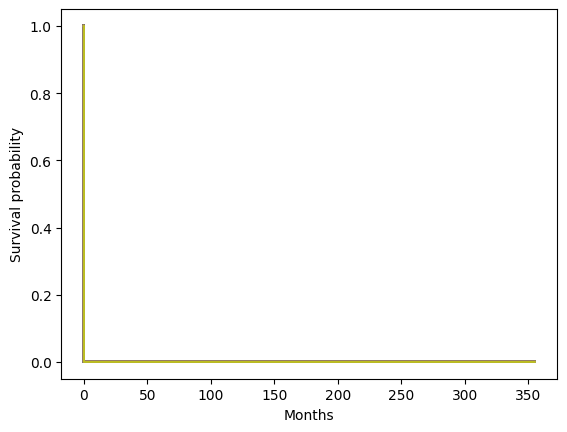

In [32]:
# Risque estimé pour chaque individu
risk_scores = cox_model.pipeline.predict(X_test)

# Liste des fonctions de survie
surv_funcs = cox_model.pipeline.named_steps["survival_model"].predict_survival_function(X_test)

# Exemple : surv_funcs[0](t) donne la probabilité de survie du premier individu à l’instant t
import matplotlib.pyplot as plt

for i, fn in enumerate(surv_funcs[50: 500]):  # afficher les 5 premiers
    plt.step(fn.x, fn(fn.x), where="post", label=f"Individu {i}")
plt.xlabel("Months")
plt.ylabel("Survival probability")
#plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_censored
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

c_indices = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_surv[train_idx], y_train_surv[val_idx]

    model = Pipeline([
        ("preprocess", preprocess),
        ("cox", CoxPHSurvivalAnalysis(alpha=0.1))
    ])

    model.fit(X_tr, y_tr)

    # prédictions de risque
    risk_scores = model.predict(X_val)

    # C-index
    c = concordance_index_censored(
        y_val["event"], 
        y_val["duration"], 
        risk_scores
    )[0]

    c_indices.append(c)

print("C-index moyen CV :", np.mean(c_indices))
print("Écart-type :", np.std(c_indices))


# Numerique features + Categorical features

In [ ]:
all_df = df.drop(subset=[topk_features])

cox_model = SurvivalModelWrapper(
    model=CoxPHSurvivalAnalysis(alpha=1, ties="breslow"),
    categorical_features=new_cat_columns,
    numerical_features=num_feature
)

C-index sur test: 0.8346569706248206


In [ ]:
# Cross validation pour tuning des hyperparamètres
param_grid = {
    "survival_model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
    "survival_model__ties": ["breslow", "efron"]
}

#cox_model.tune_parameters(df, param_grid, event_col="event", duration_col="duration", cv=5)

# Entraînement
X_test, y_test_surv = cox_model.fit(df)
print(f"Modèle entraîné. C-Index : {cox_model.c_index_:.4f}")

# Verifier la qualitée des données

In [ ]:
print(f"\nC-index sur l'ensemble de test: {c_index:.3f}")

# Tracer les courbes de survie pour différents profils de risque
from lifelines import KaplanMeierFitter

# Calculer les scores de risque
risk_scores = cph.predict_partial_hazard(df_clean[features])
df_clean['risk_score'] = risk_scores

# Créer des groupes de risque
df_clean['risk_group'] = pd.qcut(df_clean['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

# Tracer les courbes de survie pour chaque groupe de risque
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for group in ['Low', 'Medium', 'High']:
    mask = df_clean['risk_group'] == group
    kmf.fit(df_clean[mask]['duration'],
            df_clean[mask]['event'],
            label=f'{group} Risk')
    kmf.plot()

plt.title('Courbes de survie par groupe de risque')
plt.xlabel('Temps (mois)')
plt.ylabel('Probabilité de survie')
plt.grid(True)
plt.show()


C-index sur l'ensemble de test: 0.622


C:\Users\goudj\AppData\Local\Temp\ipykernel_3788\4262389960.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['risk_score'] = risk_scores
C:\Users\goudj\AppData\Local\Temp\ipykernel_3788\4262389960.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['risk_group'] = pd.qcut(df_clean['risk_score'], q=3, labels=['Low', 'Medium', 'High'])


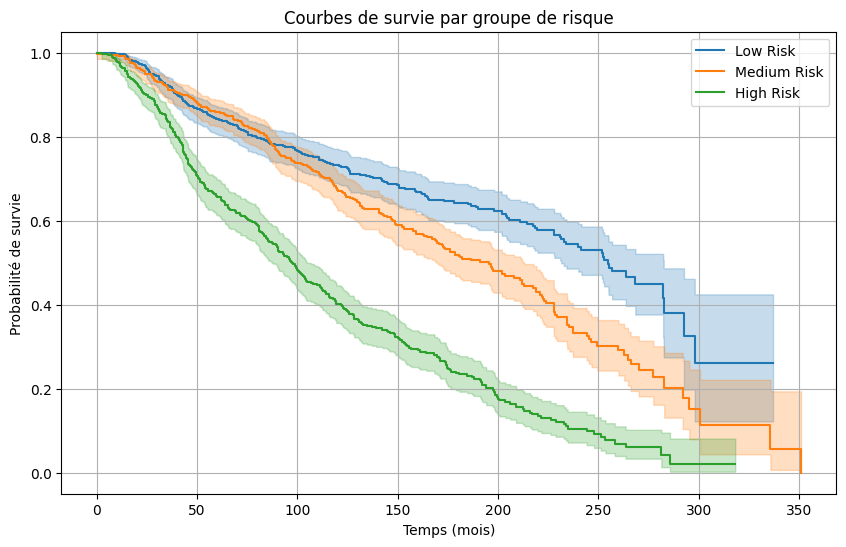

In [100]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for group in ['Low', 'Medium', 'High']:
    mask = df_clean['risk_group'] == group
    kmf.fit(df_clean[mask]['duration'],
            df_clean[mask]['event'],
            label=f'{group} Risk')
    kmf.plot()

plt.title('Courbes de survie par groupe de risque')
plt.xlabel('Temps (mois)')
plt.ylabel('Probabilité de survie')
plt.grid(True)
plt.show()